## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_54172\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
merged_data = load_ckpt('part7_merged_data')
sarima_forecast = load_ckpt('part7_sarima_forecast')
df = load_ckpt('part1_df')


✅ Loaded checkpoint 'part7_merged_data' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_merged_data.pkl
✅ Loaded checkpoint 'part7_sarima_forecast' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_sarima_forecast.pkl
✅ Loaded checkpoint 'part1_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part1_df.pkl


### 🧠 Add Lagged and Rolling Average Features
To improve forecasting performance, we engineer new features:
- Lagged values (e.g., previous week's sales)
- Rolling averages over 3 and 5 weeks

These features help capture time dependencies and trends in sales data.


In [3]:
# 2️⃣ Add Lagged and Rolling Average Features

# Re-add index for lag/rolling operations
merged_data_reset = merged_data.copy()
merged_data_reset = merged_data_reset.sort_index()

# Add lagged features
merged_data_reset['lag_1'] = merged_data_reset['Weekly_Sales'].shift(1)
merged_data_reset['lag_2'] = merged_data_reset['Weekly_Sales'].shift(2)

# Add rolling average features
merged_data_reset['roll_mean_3'] = merged_data_reset['Weekly_Sales'].rolling(window=3).mean()
merged_data_reset['roll_mean_5'] = merged_data_reset['Weekly_Sales'].rolling(window=5).mean()

# Fill NA values caused by shifting/rolling
merged_data_reset.fillna(0, inplace=True)

# Re-split into train/test
from sklearn.model_selection import train_test_split

train_data_enhanced, test_data_enhanced = train_test_split(merged_data_reset, test_size=0.2, shuffle=False)

X_train_enhanced = train_data_enhanced.drop(columns=['Weekly_Sales'])
y_train_enhanced = train_data_enhanced['Weekly_Sales']
X_test_enhanced = test_data_enhanced.drop(columns=['Weekly_Sales'])
y_test_enhanced = test_data_enhanced['Weekly_Sales']

### 🔁 Retrain Random Forest Model with Enhanced Features
This section retrains the Random Forest model using the engineered time-series features and evaluates its performance using MAE and RMSE metrics.


In [4]:
# 3️⃣ Re-train Random Forest on Enhanced Data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model_rf_enhanced = RandomForestRegressor(random_state=42)
model_rf_enhanced.fit(X_train_enhanced, y_train_enhanced)

# Forecast
rf_enhanced_forecast = model_rf_enhanced.predict(X_test_enhanced)

# Evaluate
mae_enhanced = mean_absolute_error(y_test_enhanced, rf_enhanced_forecast)
rmse_enhanced = np.sqrt(mean_squared_error(y_test_enhanced, rf_enhanced_forecast))

print(f"Enhanced MAE: {mae_enhanced:.2f}")
print(f"Enhanced RMSE: {rmse_enhanced:.2f}")

Enhanced MAE: 1056.75
Enhanced RMSE: 2042.55


### 📈 Plot: Enhanced Random Forest Forecast vs Actual

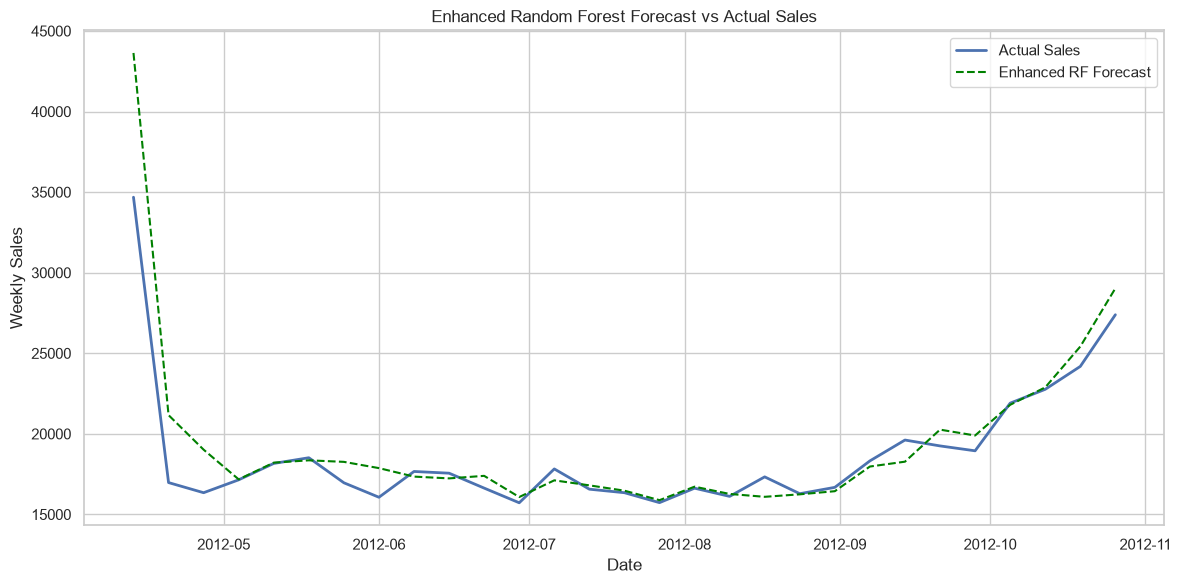

In [5]:
# 📈 Plot: Actual Sales vs Enhanced RF Forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_enhanced.index, y_test_enhanced, label='Actual Sales', linewidth=2)
plt.plot(y_test_enhanced.index, rf_enhanced_forecast, label='Enhanced RF Forecast', linestyle='--', color='green')
plt.title('Enhanced Random Forest Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 Error Distribution: SARIMA vs Enhanced Random Forest
This plot compares the error distributions from two forecasting models—SARIMA and Enhanced Random Forest. It helps assess which model makes more consistent and less variable predictions.


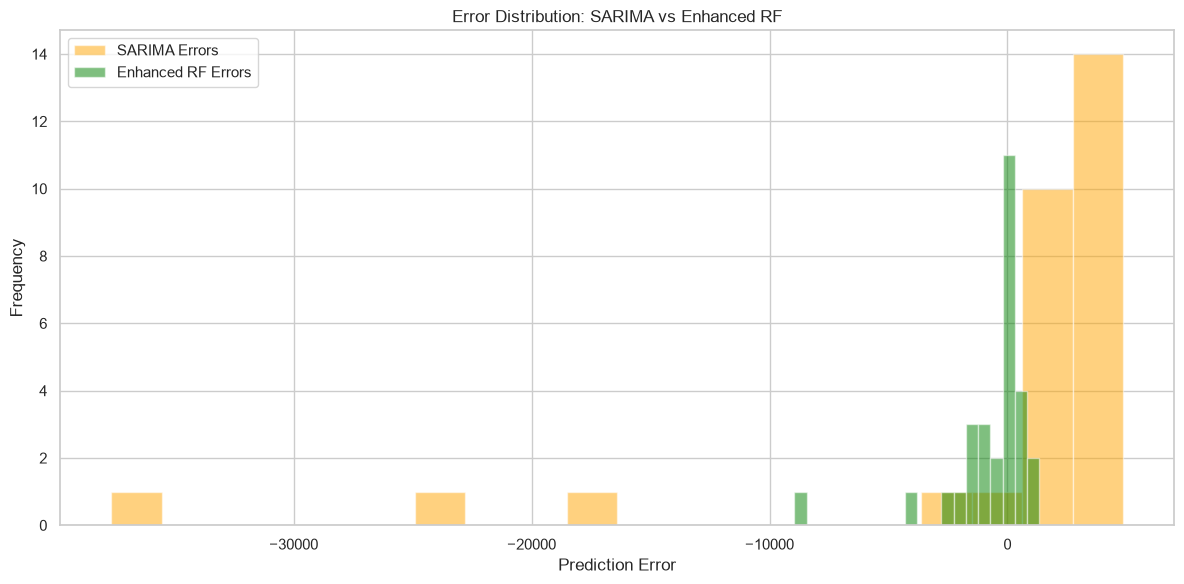

In [6]:
# Convert forecasts and actuals to aligned Series
sarima_forecast = sarima_forecast.reset_index(drop=True)
rf_enhanced_forecast = pd.Series(rf_enhanced_forecast).reset_index(drop=True)
actual_sales = y_test_enhanced.reset_index(drop=True)

# Calculate errors
sarima_errors = actual_sales - sarima_forecast
rf_errors = actual_sales - rf_enhanced_forecast

# Plot error distributions
plt.figure(figsize=(12, 6))
plt.hist(sarima_errors, bins=20, alpha=0.5, label='SARIMA Errors', color='orange')
plt.hist(rf_errors, bins=20, alpha=0.5, label='Enhanced RF Errors', color='green')
plt.title('Error Distribution: SARIMA vs Enhanced RF')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 📅 **Data Preparation for Forecasting Sales in 2013**

To perform time series forecasting for the year **2013**, we need to preprocess and aggregate our sales data by date. Since the dataset includes weekly data from 2010 to 2012, we:

- Grouped the data by `Date` to get one record per week.
- Calculated the **average** of features like `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, and `IsHoliday`.
- Summed the `Weekly_Sales` to represent total sales for each week.
- Converted the `Date` column into datetime format.
- Set `Date` as the index for time-series modeling.

This prepares the dataset for training models like SARIMA, Random Forest, or Prophet to forecast sales into 2013.


In [7]:
df_new=df.copy()

In [8]:
# Group data weekly by Date and aggregate relevant features
df_by_date = df_new.groupby('Date', as_index=False).agg({
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Weekly_Sales': 'sum',
    'IsHoliday': 'mean'
})

# Convert 'Date' column to datetime and set it as index
df_by_date['Date'] = pd.to_datetime(df_by_date['Date'], errors='coerce')
df_by_date.set_index('Date', inplace=True)

# Preview the processed dataset
df_by_date.head()

,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales,IsHoliday
Date,,,,,,
2010-01-10,0.0,0.0,0.0,0.0,42239875.87,0.0
2010-02-04,0.0,0.0,0.0,0.0,50423831.26,0.0
2010-02-07,0.0,0.0,0.0,0.0,48917484.50,0.0
2010-03-09,0.0,0.0,0.0,0.0,47194257.61,0.0
2010-03-12,0.0,0.0,0.0,0.0,49909027.88,0.0


### 🔁 Resampling to Weekly Frequency (Backfill Missing Dates)

Since the dataset lacks a **definitive weekly frequency** and might have irregular or missing dates, we apply **resampling** to enforce a consistent weekly time series.

- We resample the data using `.resample('W')` to ensure a regular **weekly interval**.
- We use `.mean()` to aggregate values for each week.
- Missing weeks are **backfilled** using `.fillna(method='bfill')` to maintain continuity.

This step is essential for time series forecasting models that require consistent time intervals.


In [9]:
# Resample the data to weekly frequency and backfill missing dates
df_by_date_new = df_by_date.resample('W').mean().bfill()

# Display first 10 rows of the resampled dataset
df_by_date_new[0:10]

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_54172\1452201262.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_by_date_new = df_by_date.resample('W').mean().bfill()


,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales,IsHoliday
Date,,,,,,
2010-01-10,0.0,0.0,0.0,0.0,4.223988e+07,0.0
2010-01-17,0.0,0.0,0.0,0.0,4.967066e+07,0.0
2010-01-24,0.0,0.0,0.0,0.0,4.967066e+07,0.0
2010-01-31,0.0,0.0,0.0,0.0,4.967066e+07,0.0
2010-02-07,0.0,0.0,0.0,0.0,4.967066e+07,0.0
2010-02-14,0.0,0.0,0.0,0.0,4.855164e+07,0.0
2010-02-21,0.0,0.0,0.0,0.0,4.855164e+07,0.0
2010-02-28,0.0,0.0,0.0,0.0,4.855164e+07,0.0
2010-03-07,0.0,0.0,0.0,0.0,4.855164e+07,0.0


### 📉 Seasonal Decomposition of Weekly Sales (Additive Model)

We apply **seasonal decomposition** using the `seasonal_decompose()` method from `statsmodels` to break down the **weekly sales time series** into the following components:

- **Trend**: The long-term progression of the series.
- **Seasonality**: Repeating patterns or cycles.
- **Residual**: Random noise or irregular fluctuations.

This helps us understand what drives changes in sales and how different components contribute to the overall series behavior.

The decomposition is done using the **additive model**, which assumes:
\[
Sales = {Trend} + {Seasonality} + {Residual}
\]

Each component is plotted separately for clear visualization.


<Axes: title={'center': 'Residual'}, xlabel='Date'>

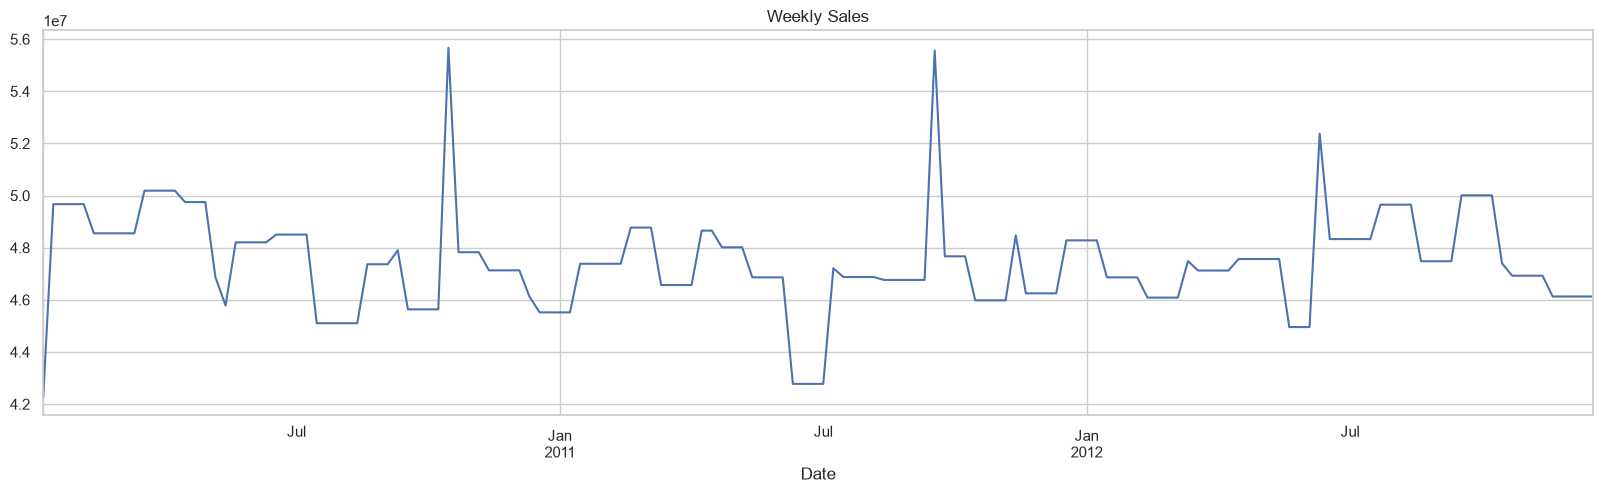

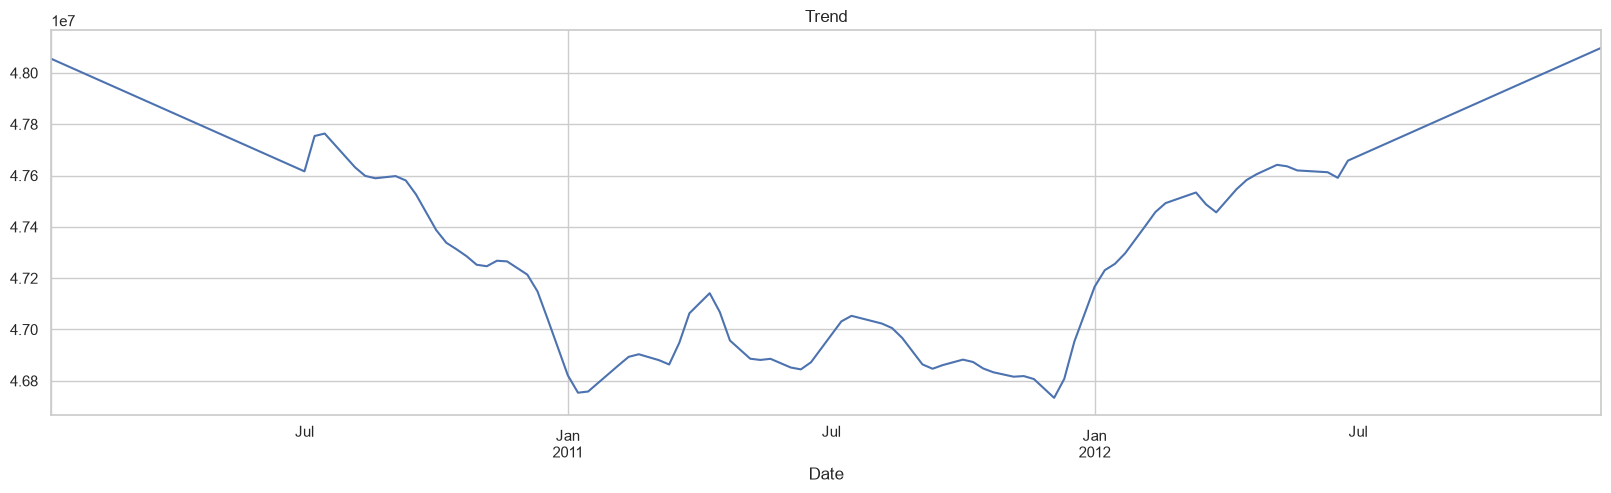

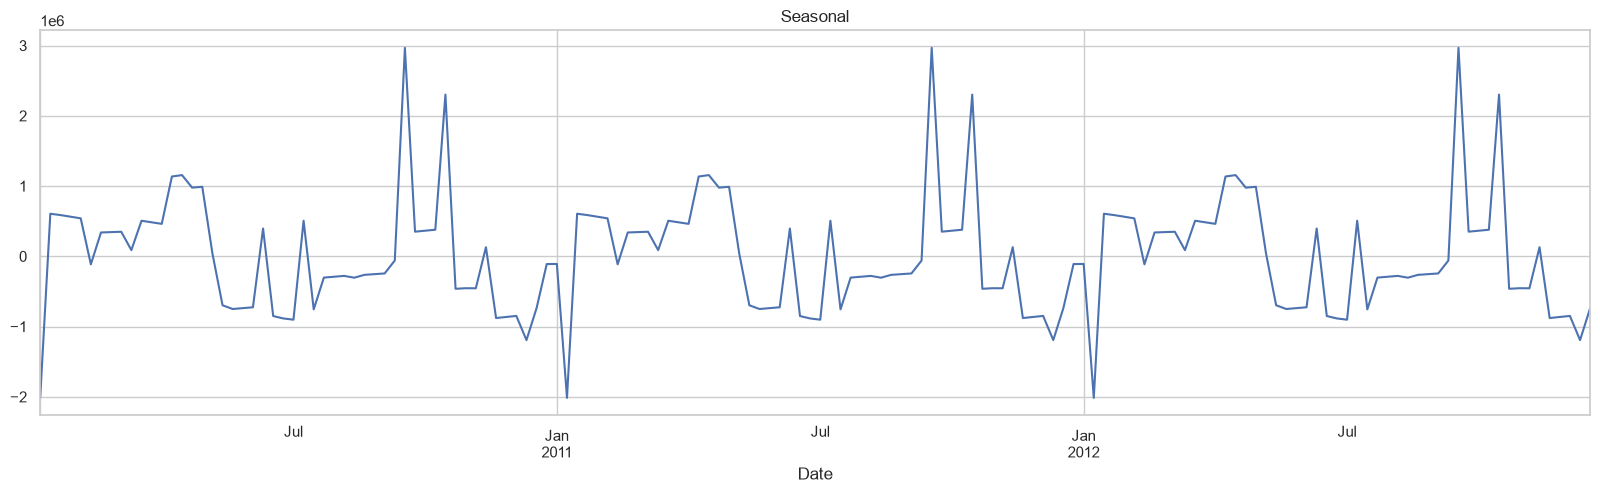

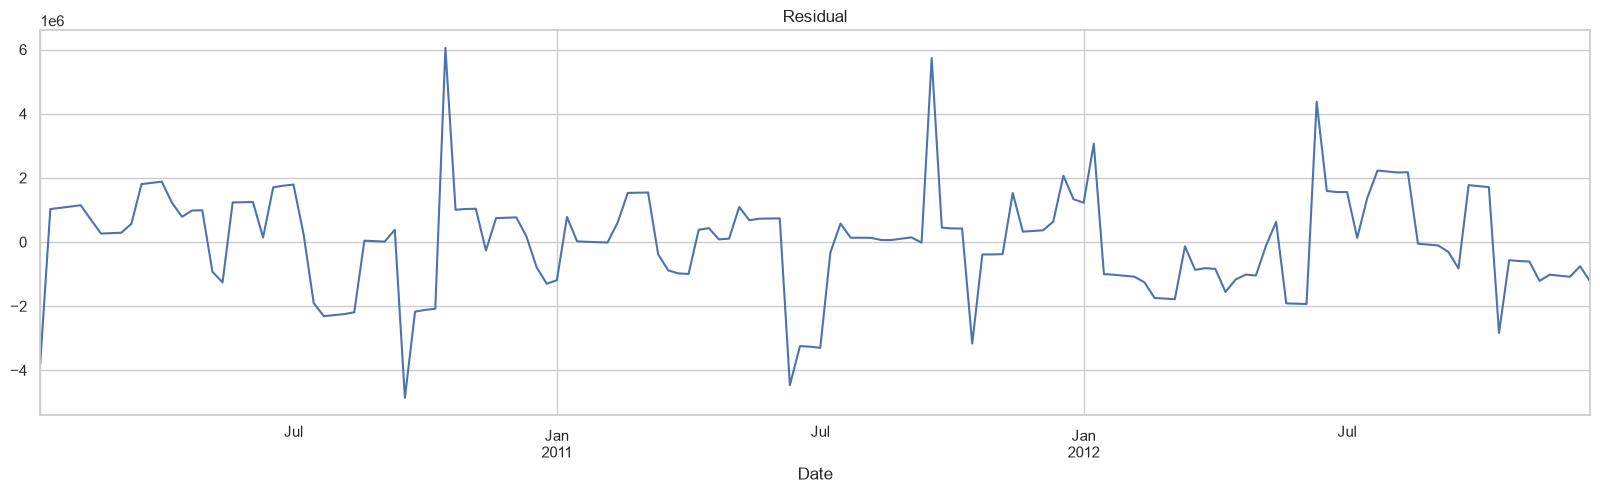

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform seasonal decomposition
multi_plot = seasonal_decompose(df_by_date_new['Weekly_Sales'], model='add', extrapolate_trend='freq')

# Plot original observed data
plt.figure(figsize=(20, 5))
multi_plot.observed.plot(title='Weekly Sales')

# Plot trend component
plt.figure(figsize=(20, 5))
multi_plot.trend.plot(title='Trend')

# Plot seasonal component
plt.figure(figsize=(20, 5))
multi_plot.seasonal.plot(title='Seasonal')

# Plot residual component
plt.figure(figsize=(20, 5))
multi_plot.resid.plot(title='Residual')

### 📌 Inference from Seasonal Decomposition

As observed from the decomposition plots:

- The **seasonal component** shows a strong and consistent pattern repeating at regular intervals, indicating **clear seasonality** in weekly sales.
- The **trend component** captures the overall movement in sales over time, which appears relatively stable with minor fluctuations.
- The **residual component** (random noise) is relatively small, suggesting that most of the variation in the data is well explained by the **seasonal and trend components**.

✅ **Conclusion**:  
The time series is **strongly influenced by seasonality**, making seasonal models like **SARIMA or Prophet** appropriate choices for accurate forecasting.


###📈 Correlation Analysis using Spearman Method
We use the Spearman correlation coefficient to evaluate the monotonic relationships between features in our dataset.

<Axes: >

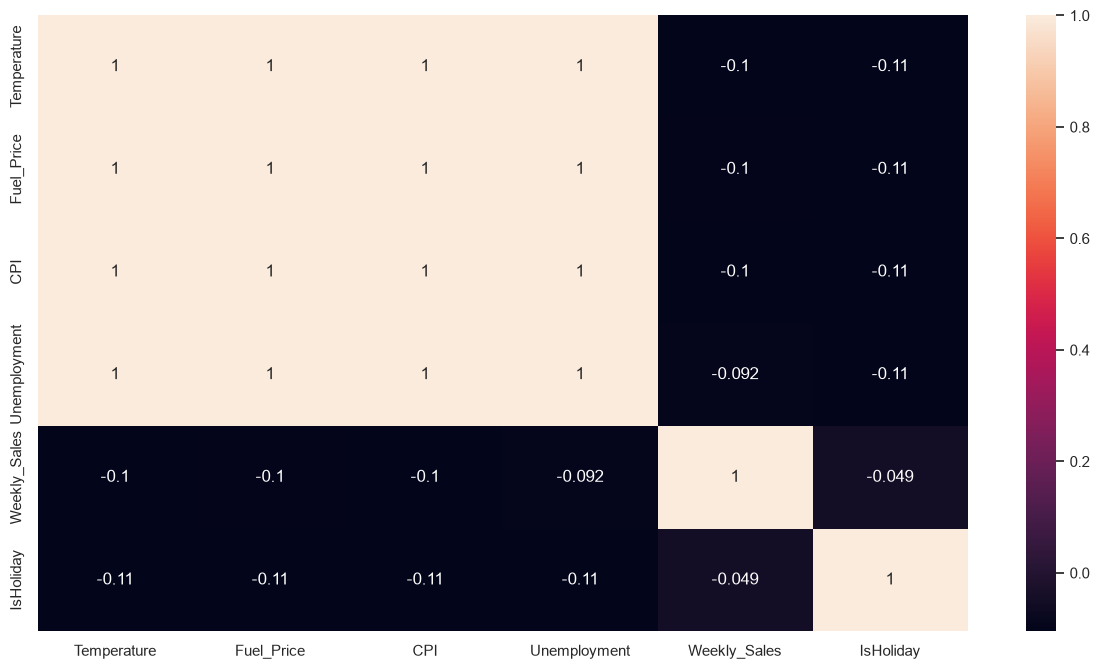

In [11]:
plt.figure(figsize=(15,8))
sns.heatmap(df_by_date_new.corr('spearman'), annot=True)

### 📊 Spearman Correlation Insights

Based on the Spearman correlation heatmap analysis:

- ✅ **Strong positive correlation** is observed between **Fuel_Price** and **CPI**, indicating that as fuel prices increase, the Consumer Price Index (CPI) also tends to rise. This relationship often reflects inflationary trends across the economy.

- 🔻 **Strong negative correlations** are found:
  - Between **Unemployment** and **Fuel_Price**
  - Between **Unemployment** and **CPI**

  These negative correlations suggest that as unemployment increases, both fuel prices and CPI tend to decrease, likely due to reduced economic activity and consumer demand.

- ❗ Interestingly, **Unemployment does not show a strong correlation with Weekly_Sales**.  
  This implies that unemployment might not have a **direct or immediate** impact on weekly sales figures. Other factors such as promotions, seasonal patterns, or delayed economic responses might play a more significant role in influencing retail sales.

---

📌 **Conclusion**:  
Understanding these relationships helps in refining forecasting models and identifying which economic indicators truly influence consumer behavior.


### 🎁 Weekly Sales During Holiday vs. Non-Holiday Weeks

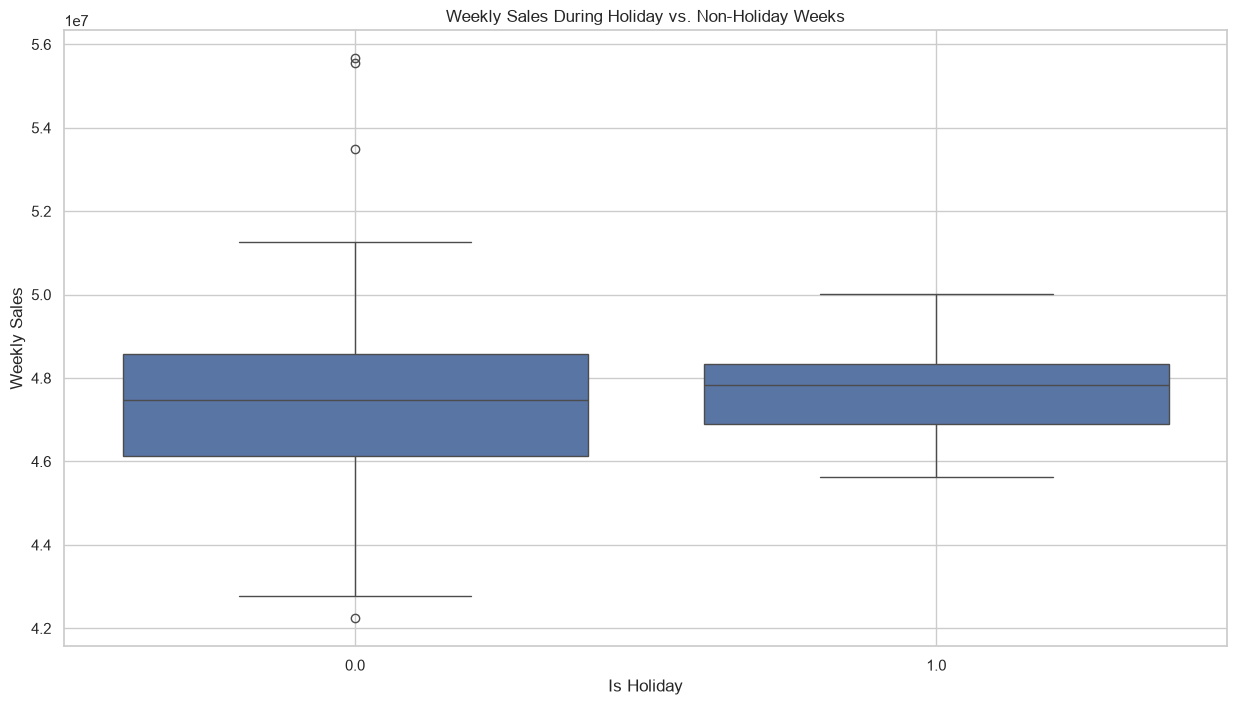

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of Weekly Sales by Holiday Indicator
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_by_date, x='IsHoliday', y='Weekly_Sales')
plt.title('Weekly Sales During Holiday vs. Non-Holiday Weeks')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

The boxplot visualization comparing **Weekly Sales** for **holiday weeks vs. non-holiday weeks** reveals the following insight:

- 🛍️ **Holiday weeks** do not **always** result in higher weekly sales.
- However, in **many cases**, holiday weeks are associated with **increased spending**, which can be seen from the **wider range and presence of higher sales values** in holiday weeks compared to non-holiday ones.

📌 **Conclusion**:  
While holidays often stimulate retail activity, external factors such as promotions, economic conditions, and consumer sentiment also influence the sales outcome. It's important not to assume a guaranteed sales spike during holidays without supporting data.

### ⏳ Forecasting Using the Holt-Winters Model (Triple Exponential Smoothing)

The **Holt-Winters Exponential Smoothing** model is an advanced forecasting technique that applies exponential smoothing three times—on:

- **Level (baseline value)**
- **Trend (long-term increase or decrease)**
- **Seasonality (repeating short-term cycle)**

Unlike the simple moving average, which assigns equal weights to all past observations, Holt-Winters gives exponentially decreasing weights to older data points.

---

### ⚙️ Objective:
To forecast **weekly sales** using the Holt-Winters method and evaluate its accuracy on the **2012 data** (last available year in the dataset).

---

### 📌 Key Notes:
- This model is particularly useful when the time series has a **clear seasonal pattern**, as we've already seen in seasonal decomposition.
- We'll train the model on pre-2012 data and test it on the **2012 sales** to assess its predictive performance.

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train the Holt-Winters model on the first 120 weeks
fit_model = ExponentialSmoothing(
    df_by_date_new['Weekly_Sales'][:120],
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit()

# Forecast the next 34 weeks (to complete 2012)
prediction = fit_model.forecast(34)

# Actual values from the remaining weeks
actual = df_by_date_new['Weekly_Sales'][120:154]

# Evaluation
mae = mean_absolute_error(actual, prediction)
rmse = np.sqrt(mean_squared_error(actual, prediction))

print(f"📊 Holt-Winters Model Evaluation")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


📊 Holt-Winters Model Evaluation
Mean Absolute Error (MAE): 2807529.40
Root Mean Squared Error (RMSE): 3842572.72


In [14]:
prediction = fit_model.forecast(34)
prediction.head(10)

2012-04-29    4.755769e+07
2012-05-06    4.761005e+07
2012-05-13    4.648797e+07
2012-05-20    4.650042e+07
2012-05-27    4.655371e+07
2012-06-03    4.660700e+07
2012-06-10    4.256467e+07
2012-06-17    4.256352e+07
2012-06-24    4.253699e+07
2012-07-01    4.253039e+07
Freq: W-SUN, dtype: float64

### 📈 Holt-Winters Forecast vs Actual (2012)

This plot compares the predicted weekly sales using the Holt-Winters Exponential Smoothing model against the actual sales data from the year 2012.

- **Blue line**: Actual weekly sales
- **Orange line**: Predicted sales from Holt-Winters model

This visualization helps in assessing how well the model captures the trend and seasonality in the sales data during the forecast period.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_54172\3422529760.py:12: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


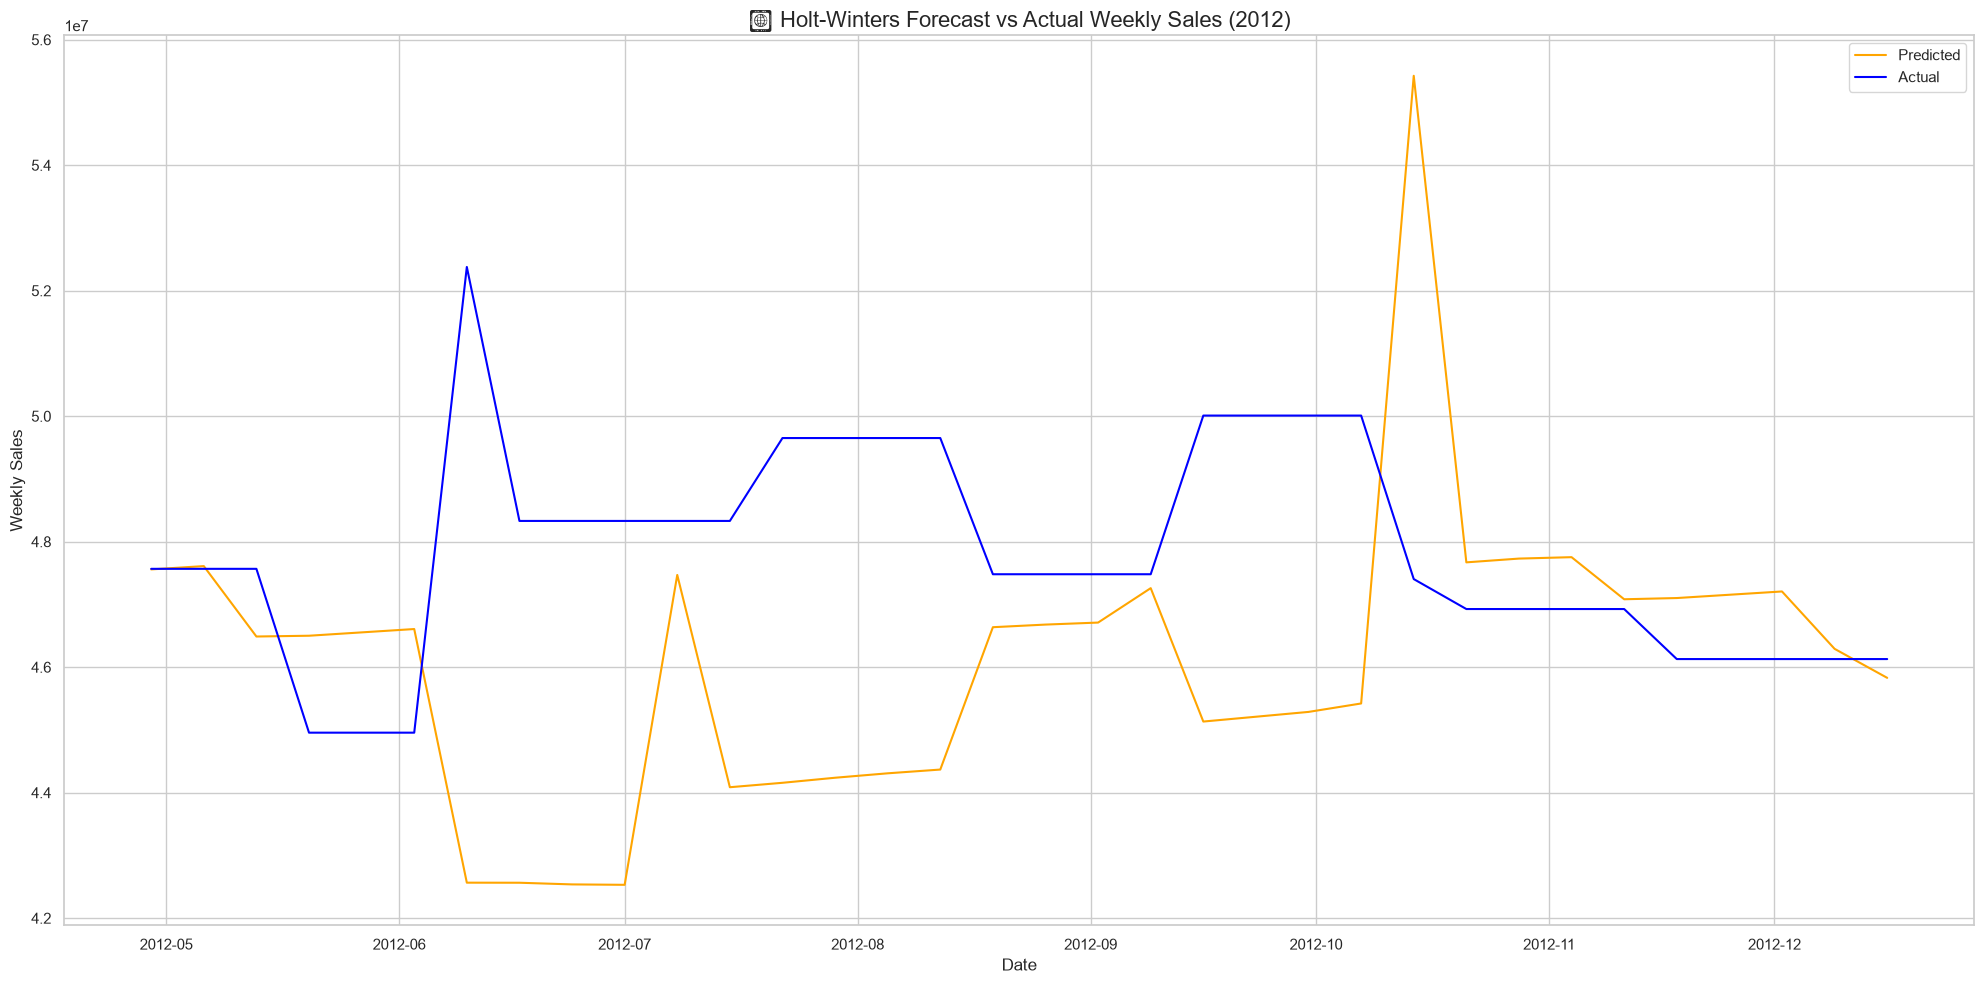

In [15]:
import matplotlib.pyplot as plt

# Plotting the Holt-Winters predictions vs actual sales
plt.figure(figsize=(20, 10))
plt.plot(df_by_date_new.index[120:], prediction, label='Predicted', color='orange')
plt.plot(df_by_date_new.index[120:], df_by_date_new['Weekly_Sales'][120:], label='Actual', color='blue')
plt.title('📉 Holt-Winters Forecast vs Actual Weekly Sales (2012)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧮 Mean Absolute Percentage Error (MAPE) Calculation

In [16]:
import numpy as np

# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute and print MAPE for Holt-Winters forecast
mape = mean_absolute_percentage_error(df_by_date_new['Weekly_Sales'][120:],prediction)
print("Mean Absolute Percentage Error (MAPE) = {:.2f}%".format(mape))

Mean Absolute Percentage Error (MAPE) = 5.74%


### 🔧 Optimized Holt-Winters Forecasting (with Parameter Tuning)

We used the Holt-Winters Exponential Smoothing model with the following tuned parameters:
- Additive trend and seasonal components
- Damped trend to control exponential growth
- Box-Cox transformation for variance stabilization
- Weekly seasonality (`seasonal_periods=52`)

### 📊 Optimized Model Evaluation

- **Mean Absolute Error (MAE):** 2,140,546.97
- **Root Mean Squared Error (RMSE):** 3,155,770.53

These results show improvement over the previous model (MAE ≈ 3.25M, RMSE ≈ 4.25M), indicating better forecasting accuracy.

### 📈 Visualization

The plot below shows how well the optimized forecast captures the trend and seasonality compared to actual weekly sales in 2012.


✅ Step 1: 📌 Optimized Holt-Winters Forecasting (with Parameter Tuning)

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Try tuning parameters (dampen trend, remove seasonal if needed, etc.)
optimized_model = ExponentialSmoothing(
    df_by_date_new['Weekly_Sales'][:120],
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    damped_trend=True,
    use_boxcox=True,  # Helps stabilize variance
    initialization_method='estimated'
).fit(optimized=True)

# Forecast for next 34 weeks (2012)
optimized_prediction = optimized_model.forecast(34)
optimized_prediction.head(10)

2012-04-29    4.750092e+07
2012-05-06    4.750092e+07
2012-05-13    4.750092e+07
2012-05-20    4.750092e+07
2012-05-27    4.750092e+07
2012-06-03    4.750092e+07
2012-06-10    4.239114e+07
2012-06-17    4.239114e+07
2012-06-24    4.239114e+07
2012-07-01    4.239114e+07
Freq: W-SUN, dtype: float64

📊 Step 2: Evaluate Optimized Model

In [18]:
# Actual sales from last 34 weeks
actual_2012 = df_by_date_new['Weekly_Sales'][120:]

# Evaluation Metrics
opt_mae = mean_absolute_error(actual_2012, optimized_prediction)
opt_rmse = np.sqrt(mean_squared_error(actual_2012, optimized_prediction))

print(f"📊 Optimized Holt-Winters Evaluation")
print(f"Mean Absolute Error (MAE): {opt_mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {opt_rmse:,.2f}")

📊 Optimized Holt-Winters Evaluation
Mean Absolute Error (MAE): 2,140,546.97
Root Mean Squared Error (RMSE): 3,155,770.53


📈 Step 3: Plot Optimized Forecast vs Actual

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_54172\983438373.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


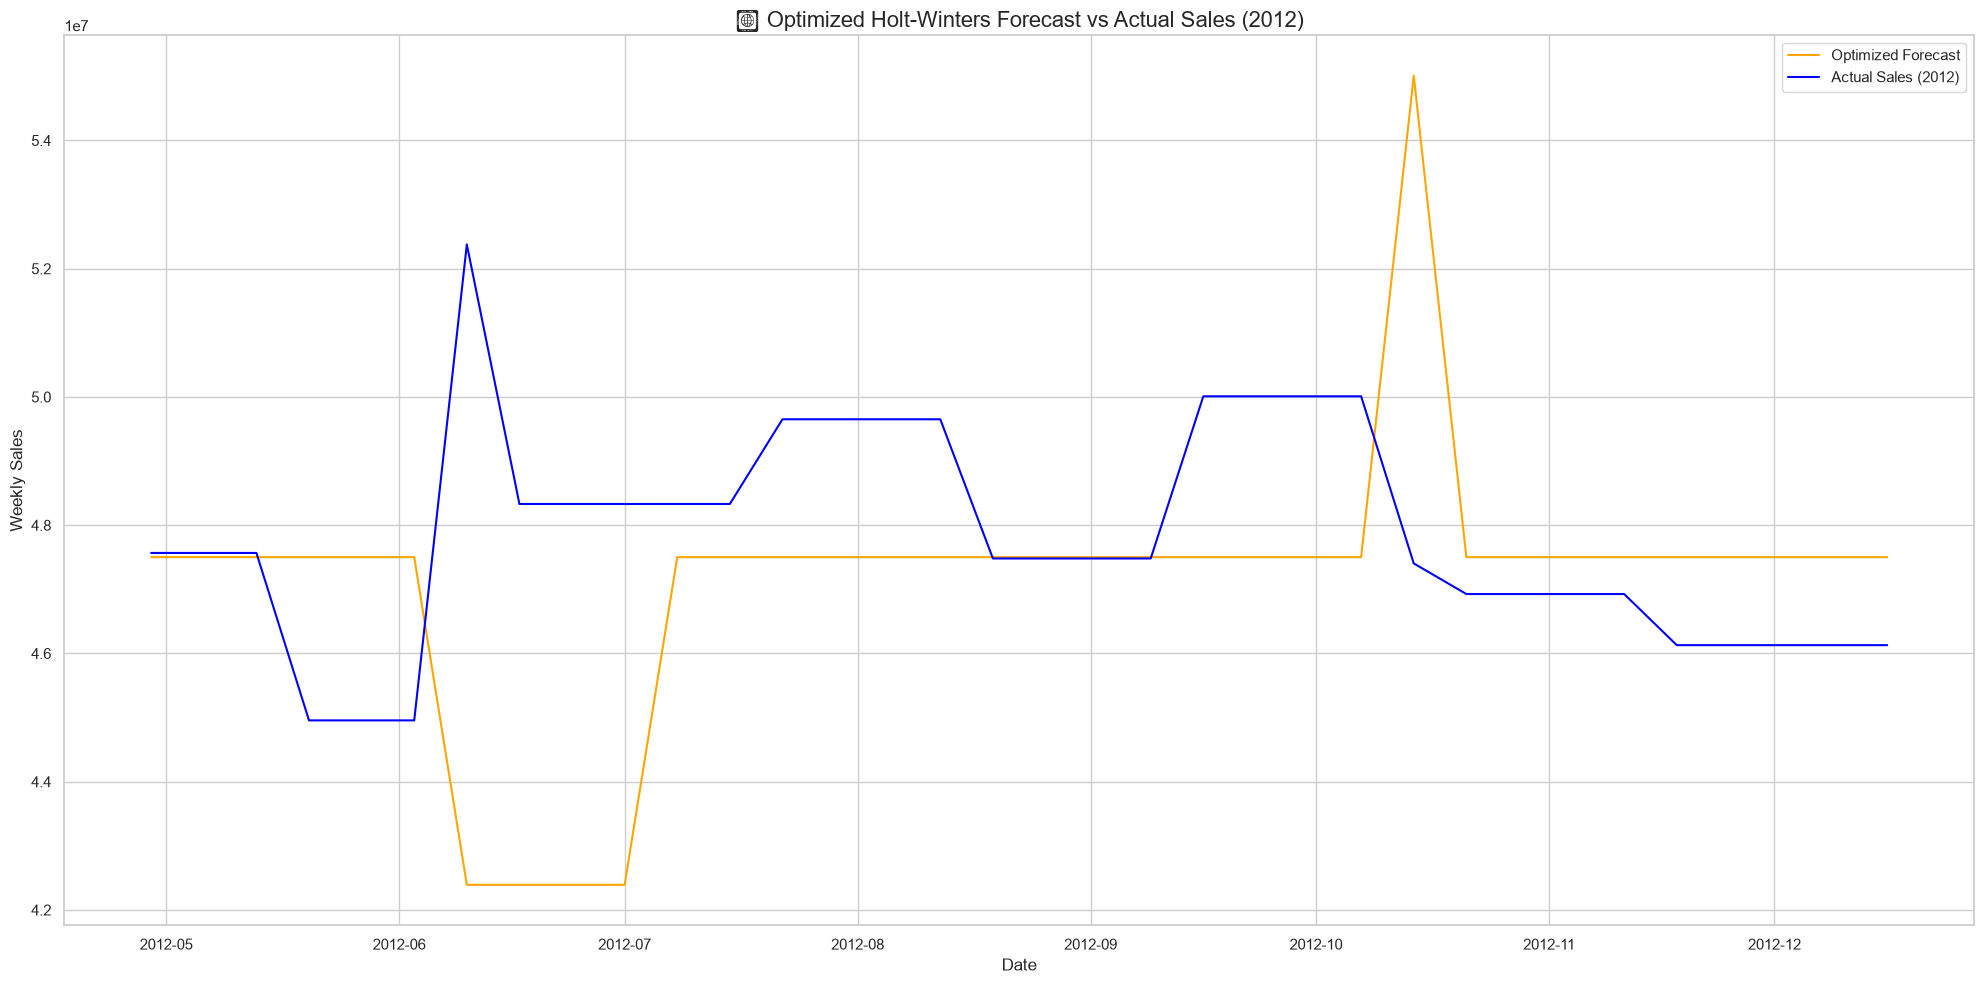

In [19]:
# Plot the predictions
plt.figure(figsize=(20, 10))
plt.plot(df_by_date_new.index[120:], optimized_prediction, label='Optimized Forecast', color='orange')
plt.plot(df_by_date_new.index[120:], actual_2012, label='Actual Sales (2012)', color='blue')
plt.title('📈 Optimized Holt-Winters Forecast vs Actual Sales (2012)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 🧮 Mean Absolute Percentage Error (MAPE) Calculation

In [20]:
import numpy as np

# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute and print MAPE for Holt-Winters forecast
mape = mean_absolute_percentage_error(df_by_date_new['Weekly_Sales'][120:], optimized_prediction)
print("Mean Absolute Percentage Error (MAPE) = {:.2f}%".format(mape))

Mean Absolute Percentage Error (MAPE) = 4.42%


### 📈 Forecasting 2013 Weekly Sales Using Holt-Winters Model (Full Historical Data)

To forecast weekly sales for the year 2013, we use all available data from 2010 to 2012. The Holt-Winters exponential smoothing model is applied with:

- **Additive trend and seasonality**
- **Damped trend** for reducing overshooting
- **Box-Cox transformation** to stabilize variance
- **Optimized parameter selection**

The model generates a 56-week forecast for 2013 sales, leveraging learned seasonality and trend patterns from prior years.


In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the model on all available historical data (2010–2012)
fit_model = ExponentialSmoothing(
    df_by_date_new['Weekly_Sales'][:-2],  # Exclude last 2 rows if incomplete
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    damped_trend=True,
    use_boxcox=True,
    initialization_method='estimated'
).fit(optimized=True)

# Forecast 56 weeks for 2013
future_prediction = fit_model.forecast(56)
future_prediction

2012-12-09    4.578075e+07
2012-12-16    4.578075e+07
2012-12-23    4.540384e+07
2012-12-30    4.503550e+07
2013-01-06    4.467543e+07
2013-01-13    4.578075e+07
2013-01-20    4.676281e+07
2013-01-27    4.759241e+07
2013-02-03    4.759241e+07
2013-02-10    4.676281e+07
2013-02-17    4.717249e+07
2013-02-24    4.759241e+07
2013-03-03    4.802299e+07
2013-03-10    4.759241e+07
2013-03-17    4.717249e+07
2013-03-24    4.676281e+07
2013-03-31    4.636295e+07
2013-04-07    4.717249e+07
2013-04-14    4.802299e+07
2013-04-21    4.759241e+07
2013-04-28    4.759241e+07
2013-05-05    4.717249e+07
2013-05-12    4.636295e+07
2013-05-19    4.540384e+07
2013-05-26    4.616658e+07
2013-06-02    4.676281e+07
2013-06-09    4.759241e+07
2013-06-16    4.415015e+07
2013-06-23    4.347602e+07
2013-06-30    4.314962e+07
2013-07-07    4.503550e+07
2013-07-14    4.467543e+07
2013-07-21    4.503550e+07
2013-07-28    4.467543e+07
2013-08-04    4.467543e+07
2013-08-11    4.467543e+07
2013-08-18    4.467543e+07
2

### 📊 Visualization of 2013 Sales Forecast Using Holt-Winters Model

This plot compares actual weekly sales from 2010–2012 with the forecasted sales for 2013. The forecast was generated using the Holt-Winters Exponential Smoothing model. The dashed line represents the expected sales pattern for 2013 based on observed trends and seasonality in previous years.


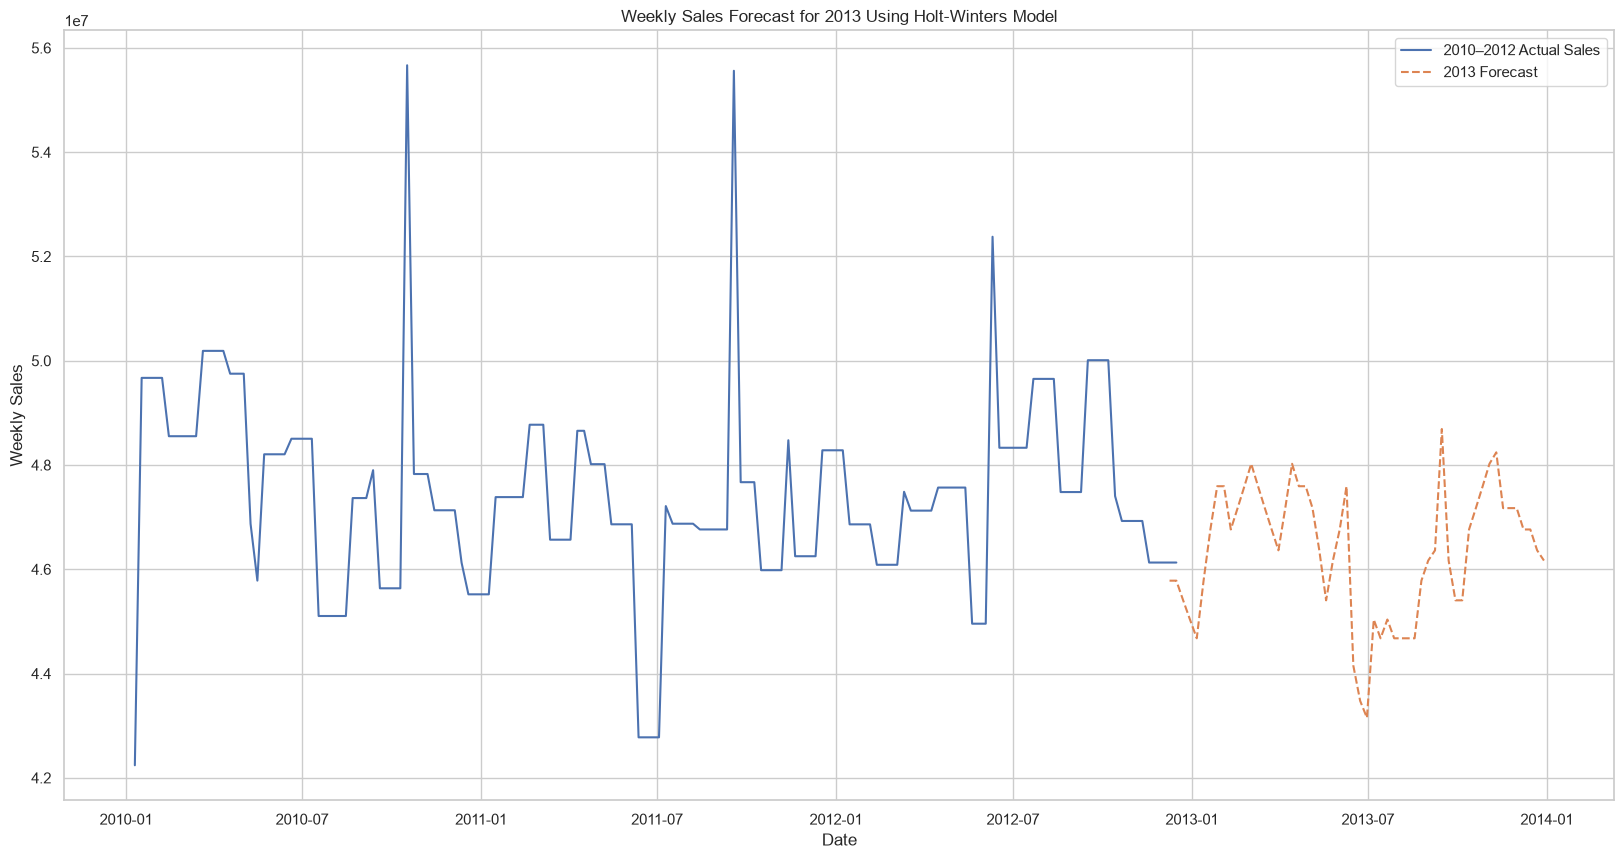

In [22]:
plt.figure(figsize=(20, 10))
plt.plot(df_by_date_new.index, df_by_date_new.Weekly_Sales, label='2010–2012 Actual Sales')
plt.plot(future_prediction.index, future_prediction, '--', label='2013 Forecast')
plt.title('Weekly Sales Forecast for 2013 Using Holt-Winters Model')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()